In [1]:
# ============================================================
# PHASE 2 — Modèles ML
# Cellule 1 : Chargement des données de Phase 1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Charger les données sauvegardées en Phase 1
processed_dir = r"C:\PFA_Malware\data\processed"

# CIC-MalMem
X_m_train = np.load(os.path.join(processed_dir, "malmem_X_train.npy"))
X_m_val   = np.load(os.path.join(processed_dir, "malmem_X_val.npy"))
X_m_test  = np.load(os.path.join(processed_dir, "malmem_X_test.npy"))
y_m_train = np.load(os.path.join(processed_dir, "malmem_y_train.npy"))
y_m_val   = np.load(os.path.join(processed_dir, "malmem_y_val.npy"))
y_m_test  = np.load(os.path.join(processed_dir, "malmem_y_test.npy"))

# EMBER
X_e_train = np.load(os.path.join(processed_dir, "ember_X_train.npy"))
X_e_val   = np.load(os.path.join(processed_dir, "ember_X_val.npy"))
X_e_test  = np.load(os.path.join(processed_dir, "ember_X_test.npy"))
y_e_train = np.load(os.path.join(processed_dir, "ember_y_train.npy"))
y_e_val   = np.load(os.path.join(processed_dir, "ember_y_val.npy"))
y_e_test  = np.load(os.path.join(processed_dir, "ember_y_test.npy"))

print("=== Données chargées ===")
print(f"CIC-MalMem : Train {X_m_train.shape} | Val {X_m_val.shape} | Test {X_m_test.shape}")
print(f"EMBER      : Train {X_e_train.shape} | Val {X_e_val.shape} | Test {X_e_test.shape}")
print("\n✅ Phase 2 prête à démarrer !")

=== Données chargées ===
CIC-MalMem : Train (40623, 28) | Val (8705, 28) | Test (8705, 28)
EMBER      : Train (480000, 200) | Val (120000, 200) | Test (200000, 200)

✅ Phase 2 prête à démarrer !


In [5]:
# ============================================================
# Cellule 2 : Fonction d'évaluation + Baselines
# ============================================================

def evaluate_model(model, X_val, y_val, model_name, dataset_name):
    """Évalue un modèle et retourne toutes les métriques."""
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {
        'Model'    : model_name,
        'Dataset'  : dataset_name,
        'Accuracy' : round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall'   : round(recall_score(y_val, y_pred), 4),
        'F1'       : round(f1_score(y_val, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_val, y_proba), 4)
    }
    
    print(f"\n── {model_name} | {dataset_name} ──")
    for k, v in metrics.items():
        if k not in ['Model', 'Dataset']:
            print(f"  {k:<10} : {v}")
    
    return metrics

results_baseline = []

# ── RANDOM FOREST ─────────────────────────────────────────
print("="*55)
print("RANDOM FOREST — Baseline")
print("="*55)

# CIC-MalMem
rf_malmem = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_malmem.fit(X_m_train, y_m_train)
results_baseline.append(evaluate_model(rf_malmem, X_m_val, y_m_val, "RF", "CIC-MalMem"))

# EMBER
rf_ember = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ember.fit(X_e_train, y_e_train)
results_baseline.append(evaluate_model(rf_ember, X_e_val, y_e_val, "RF", "EMBER"))

# ── XGBOOST ───────────────────────────────────────────────
print("\n" + "="*55)
print("XGBOOST — Baseline")
print("="*55)

# CIC-MalMem
xgb_malmem = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                                 eval_metric='logloss', verbosity=0)
xgb_malmem.fit(X_m_train, y_m_train)
results_baseline.append(evaluate_model(xgb_malmem, X_m_val, y_m_val, "XGBoost", "CIC-MalMem"))

# EMBER
xgb_ember = xgb.XGBClassifier(n_estimators=100, random_state=42,
                                eval_metric='logloss', verbosity=0)
xgb_ember.fit(X_e_train, y_e_train)
results_baseline.append(evaluate_model(xgb_ember, X_e_val, y_e_val, "XGBoost", "EMBER"))

# ── LIGHTGBM ──────────────────────────────────────────────
print("\n" + "="*55)
print("LIGHTGBM — Baseline")
print("="*55)

# CIC-MalMem
lgb_malmem = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_malmem.fit(X_m_train, y_m_train)
results_baseline.append(evaluate_model(lgb_malmem, X_m_val, y_m_val, "LightGBM", "CIC-MalMem"))

# EMBER
lgb_ember = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_ember.fit(X_e_train, y_e_train)
results_baseline.append(evaluate_model(lgb_ember, X_e_val, y_e_val, "LightGBM", "EMBER"))

# ── Tableau récapitulatif ──────────────────────────────────
print("\n" + "="*55)
print("TABLEAU RÉCAPITULATIF — Baselines")
print("="*55)
df_baseline = pd.DataFrame(results_baseline)
print(df_baseline.to_string(index=False))

print("\n✅ Baselines terminées — prêt pour le tuning Optuna")

RANDOM FOREST — Baseline

── RF | CIC-MalMem ──
  Accuracy   : 1.0
  Precision  : 1.0
  Recall     : 1.0
  F1         : 1.0
  AUC-ROC    : 1.0

── RF | EMBER ──
  Accuracy   : 0.9558
  Precision  : 0.9585
  Recall     : 0.953
  F1         : 0.9557
  AUC-ROC    : 0.9929

XGBOOST — Baseline

── XGBoost | CIC-MalMem ──
  Accuracy   : 0.9999
  Precision  : 1.0
  Recall     : 0.9998
  F1         : 0.9999
  AUC-ROC    : 1.0

── XGBoost | EMBER ──
  Accuracy   : 0.9437
  Precision  : 0.9427
  Recall     : 0.9448
  F1         : 0.9437
  AUC-ROC    : 0.9884

LIGHTGBM — Baseline

── LightGBM | CIC-MalMem ──
  Accuracy   : 1.0
  Precision  : 1.0
  Recall     : 1.0
  F1         : 1.0
  AUC-ROC    : 1.0

── LightGBM | EMBER ──
  Accuracy   : 0.9247
  Precision  : 0.9193
  Recall     : 0.9311
  F1         : 0.9252
  AUC-ROC    : 0.9808

TABLEAU RÉCAPITULATIF — Baselines
   Model    Dataset  Accuracy  Precision  Recall     F1  AUC-ROC
      RF CIC-MalMem    1.0000     1.0000  1.0000 1.0000   1.0000
 

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20

# ── FONCTIONS OBJECTIF ─────────────────────────────────────

def objective_rf(trial, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 300),
        'max_depth'        : trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state'     : 42,
        'n_jobs'           : -1
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    return f1_score(y_val, model.predict(X_val))


def objective_xgb(trial, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : 42,
        'eval_metric'      : 'logloss',
        'verbosity'        : 0,
        'n_jobs'           : -1,
        'early_stopping_rounds' : 20
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    return f1_score(y_val, model.predict(X_val))


def objective_lgb(trial, X_train, y_train, X_val, y_val):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'    : 42,
        'verbose'         : -1,
        'n_jobs'          : -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(20, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    return f1_score(y_val, model.predict(X_val))


# ── RANDOM FOREST ──────────────────────────────────────────
print("="*55)
print("OPTUNA — Random Forest")
print("="*55)

study_rf_m = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_m.optimize(lambda t: objective_rf(t, X_m_train, y_m_train, X_m_val, y_m_val),
                    n_trials=N_TRIALS, show_progress_bar=True)
print(f"✅ RF CIC-MalMem — F1 : {study_rf_m.best_value:.4f} | {study_rf_m.best_params}")

study_rf_e = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_e.optimize(lambda t: objective_rf(t, X_e_train, y_e_train, X_e_val, y_e_val),
                    n_trials=10,
                    timeout=3600,
                    show_progress_bar=True)
print(f"✅ RF EMBER — F1 : {study_rf_e.best_value:.4f} | {study_rf_e.best_params}")


# ── XGBOOST ────────────────────────────────────────────────
print("\n" + "="*55)
print("OPTUNA — XGBoost")
print("="*55)

study_xgb_m = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb_m.optimize(lambda t: objective_xgb(t, X_m_train, y_m_train, X_m_val, y_m_val),
                     n_trials=N_TRIALS, show_progress_bar=True)
print(f"✅ XGBoost CIC-MalMem — F1 : {study_xgb_m.best_value:.4f} | {study_xgb_m.best_params}")

study_xgb_e = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb_e.optimize(lambda t: objective_xgb(t, X_e_train, y_e_train, X_e_val, y_e_val),
                     n_trials=N_TRIALS, show_progress_bar=True)
print(f"✅ XGBoost EMBER — F1 : {study_xgb_e.best_value:.4f} | {study_xgb_e.best_params}")


# ── LIGHTGBM ───────────────────────────────────────────────
print("\n" + "="*55)
print("OPTUNA — LightGBM")
print("="*55)

study_lgb_m = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_m.optimize(lambda t: objective_lgb(t, X_m_train, y_m_train, X_m_val, y_m_val),
                     n_trials=N_TRIALS, show_progress_bar=True)
print(f"✅ LightGBM CIC-MalMem — F1 : {study_lgb_m.best_value:.4f} | {study_lgb_m.best_params}")

study_lgb_e = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_e.optimize(lambda t: objective_lgb(t, X_e_train, y_e_train, X_e_val, y_e_val),
                     n_trials=N_TRIALS, show_progress_bar=True)
print(f"✅ LightGBM EMBER — F1 : {study_lgb_e.best_value:.4f} | {study_lgb_e.best_params}")

print("\n🎉 Tuning Optuna terminé pour les 3 modèles !")

OPTUNA — Random Forest


  0%|          | 0/20 [00:00<?, ?it/s]

✅ RF CIC-MalMem — F1 : 0.9999 | {'n_estimators': 186, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}


  0%|          | 0/10 [00:00<?, ?it/s]

✅ RF EMBER — F1 : 0.9324 | {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}

OPTUNA — XGBoost


...

✅ XGBoost EMBER — F1 : 0.9714 | {'n_estimators': 486, 'max_depth': 10, 'learning_rate': 0.1744115940116885, 'subsample': 0.7606682033441123, 'colsample_bytree': 0.7238803118866866, 'reg_alpha': 0.47266129259711465, 'reg_lambda': 8.748558229622195e-08}

OPTUNA — LightGBM


  0%|          | 0/20 [00:00<?, ?it/s]

✅ LightGBM CIC-MalMem — F1 : 1.0000 | {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 98, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}


  0%|          | 0/20 [00:00<?, ?it/s]

✅ LightGBM EMBER — F1 : 0.9657 | {'n_estimators': 414, 'max_depth': 12, 'learning_rate': 0.12773505139998823, 'num_leaves': 97, 'subsample': 0.6085582193565989, 'colsample_bytree': 0.7481951431880141, 'reg_alpha': 4.077391468444027e-08, 'reg_lambda': 2.833985742575914}

🎉 Tuning Optuna terminé pour les 3 modèles !


In [7]:
# ============================================================
# Cellule 4 : Entraînement final sur Train+Val + Évaluation
# ============================================================

# Concaténer train + val pour le modèle final
X_m_trainval = np.concatenate([X_m_train, X_m_val], axis=0)
y_m_trainval = np.concatenate([y_m_train, y_m_val], axis=0)
X_e_trainval = np.concatenate([X_e_train, X_e_val], axis=0)
y_e_trainval = np.concatenate([y_e_train, y_e_val], axis=0)

print(f"CIC-MalMem Train+Val : {X_m_trainval.shape}")
print(f"EMBER      Train+Val : {X_e_trainval.shape}")

def evaluate_model(model, X, y, model_name, dataset_name, split):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model'    : model_name,
        'Dataset'  : dataset_name,
        'Split'    : split,
        'Accuracy' : round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred), 4),
        'Recall'   : round(recall_score(y, y_pred), 4),
        'F1'       : round(f1_score(y, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y, y_proba), 4)
    }

results_final = []

# ── RANDOM FOREST ──────────────────────────────────────────
print("\n" + "="*55)
print("RF Final — Train+Val → évaluation Test")
print("="*55)

rf_malmem_final = RandomForestClassifier(**study_rf_m.best_params,
                                          random_state=42, n_jobs=-1)
rf_malmem_final.fit(X_m_trainval, y_m_trainval)
results_final.append(evaluate_model(rf_malmem_final, X_m_test, y_m_test, "RF", "CIC-MalMem", "Test"))
print(f"✅ RF CIC-MalMem — Test F1 : {results_final[-1]['F1']}")

rf_ember_final = RandomForestClassifier(**study_rf_e.best_params,
                                         random_state=42, n_jobs=-1)
rf_ember_final.fit(X_e_trainval, y_e_trainval)
results_final.append(evaluate_model(rf_ember_final, X_e_test, y_e_test, "RF", "EMBER", "Test"))
print(f"✅ RF EMBER — Test F1 : {results_final[-1]['F1']}")

# ── XGBOOST ────────────────────────────────────────────────
print("\n" + "="*55)
print("XGBoost Final — Train+Val → évaluation Test")
print("="*55)

xgb_malmem_final = xgb.XGBClassifier(**study_xgb_m.best_params,
                                       random_state=42, verbosity=0, n_jobs=-1)
xgb_malmem_final.fit(X_m_trainval, y_m_trainval)
results_final.append(evaluate_model(xgb_malmem_final, X_m_test, y_m_test, "XGBoost", "CIC-MalMem", "Test"))
print(f"✅ XGBoost CIC-MalMem — Test F1 : {results_final[-1]['F1']}")

xgb_ember_final = xgb.XGBClassifier(**study_xgb_e.best_params,
                                      random_state=42, verbosity=0, n_jobs=-1)
xgb_ember_final.fit(X_e_trainval, y_e_trainval)
results_final.append(evaluate_model(xgb_ember_final, X_e_test, y_e_test, "XGBoost", "EMBER", "Test"))
print(f"✅ XGBoost EMBER — Test F1 : {results_final[-1]['F1']}")

# ── LIGHTGBM ───────────────────────────────────────────────
print("\n" + "="*55)
print("LightGBM Final — Train+Val → évaluation Test")
print("="*55)

lgb_malmem_final = lgb.LGBMClassifier(**study_lgb_m.best_params,
                                        random_state=42, verbose=-1, n_jobs=-1)
lgb_malmem_final.fit(X_m_trainval, y_m_trainval)
results_final.append(evaluate_model(lgb_malmem_final, X_m_test, y_m_test, "LightGBM", "CIC-MalMem", "Test"))
print(f"✅ LightGBM CIC-MalMem — Test F1 : {results_final[-1]['F1']}")

lgb_ember_final = lgb.LGBMClassifier(**study_lgb_e.best_params,
                                       random_state=42, verbose=-1, n_jobs=-1)
lgb_ember_final.fit(X_e_trainval, y_e_trainval)
results_final.append(evaluate_model(lgb_ember_final, X_e_test, y_e_test, "LightGBM", "EMBER", "Test"))
print(f"✅ LightGBM EMBER — Test F1 : {results_final[-1]['F1']}")

# ── Tableau final ───────────────────────────────────────────
print("\n" + "="*65)
print("TABLEAU FINAL — Performances sur Test Set")
print("="*65)
df_final = pd.DataFrame(results_final)
print(df_final.to_string(index=False))

# ── Tableau comparatif 3 niveaux ────────────────────────────
print("\n" + "="*65)
print("TABLEAU COMPARATIF — Baseline → Tuned(Val) → Final(Test)")
print("="*65)
df_baseline_f1 = pd.DataFrame(results_baseline)[['Model','Dataset','F1']].rename(
    columns={'F1':'F1_baseline'})
df_tuned_f1 = pd.DataFrame(results_baseline)[['Model','Dataset']].copy()

# Recalcul val scores avec modèles finaux
val_scores = []
for model, name, Xv, yv, ds in [
    (rf_malmem_final,  "RF",       X_m_val, y_m_val, "CIC-MalMem"),
    (rf_ember_final,   "RF",       X_e_val, y_e_val, "EMBER"),
    (xgb_malmem_final, "XGBoost",  X_m_val, y_m_val, "CIC-MalMem"),
    (xgb_ember_final,  "XGBoost",  X_e_val, y_e_val, "EMBER"),
    (lgb_malmem_final, "LightGBM", X_m_val, y_m_val, "CIC-MalMem"),
    (lgb_ember_final,  "LightGBM", X_e_val, y_e_val, "EMBER"),
]:
    val_scores.append({
        'Model'  : name,
        'Dataset': ds,
        'F1_val' : round(f1_score(yv, model.predict(Xv)), 4)
    })

df_compare = df_baseline_f1.merge(
    pd.DataFrame(val_scores), on=['Model','Dataset']
).merge(
    df_final[['Model','Dataset','F1']].rename(columns={'F1':'F1_test'}),
    on=['Model','Dataset']
)
df_compare['Gain_tuning'] = (df_compare['F1_val'] - df_compare['F1_baseline']).round(4)
df_compare['Gain_final']  = (df_compare['F1_test'] - df_compare['F1_baseline']).round(4)
print(df_compare.to_string(index=False))

print("\n✅ Évaluation complète et rigoureuse terminée !")

CIC-MalMem Train+Val : (49328, 28)
EMBER      Train+Val : (600000, 200)

RF Final — Train+Val → évaluation Test
✅ RF CIC-MalMem — Test F1 : 1.0
✅ RF EMBER — Test F1 : 0.9096

XGBoost Final — Train+Val → évaluation Test
✅ XGBoost CIC-MalMem — Test F1 : 0.9998
✅ XGBoost EMBER — Test F1 : 0.957

LightGBM Final — Train+Val → évaluation Test
✅ LightGBM CIC-MalMem — Test F1 : 1.0
✅ LightGBM EMBER — Test F1 : 0.9513

TABLEAU FINAL — Performances sur Test Set
   Model    Dataset Split  Accuracy  Precision  Recall     F1  AUC-ROC
      RF CIC-MalMem  Test    1.0000     1.0000  1.0000 1.0000   1.0000
      RF      EMBER  Test    0.9072     0.8873  0.9329 0.9096   0.9709
 XGBoost CIC-MalMem  Test    0.9998     1.0000  0.9995 0.9998   1.0000
 XGBoost      EMBER  Test    0.9570     0.9561  0.9580 0.9570   0.9905
LightGBM CIC-MalMem  Test    1.0000     1.0000  1.0000 1.0000   1.0000
LightGBM      EMBER  Test    0.9510     0.9459  0.9568 0.9513   0.9891

TABLEAU COMPARATIF — Baseline → Tuned(Val) → F

In [8]:
# Vérification avant sauvegarde
print("Variables disponibles :")
print(f"  rf_malmem_final  : {'✅' if 'rf_malmem_final' in dir() else '❌'}")
print(f"  rf_ember_final   : {'✅' if 'rf_ember_final' in dir() else '❌'}")
print(f"  xgb_malmem_final : {'✅' if 'xgb_malmem_final' in dir() else '❌'}")
print(f"  xgb_ember_final  : {'✅' if 'xgb_ember_final' in dir() else '❌'}")
print(f"  lgb_malmem_final : {'✅' if 'lgb_malmem_final' in dir() else '❌'}")
print(f"  lgb_ember_final  : {'✅' if 'lgb_ember_final' in dir() else '❌'}")
print(f"  study_rf_m       : {'✅' if 'study_rf_m' in dir() else '❌'}")
print(f"  study_rf_e       : {'✅' if 'study_rf_e' in dir() else '❌'}")
print(f"  study_xgb_m      : {'✅' if 'study_xgb_m' in dir() else '❌'}")
print(f"  study_xgb_e      : {'✅' if 'study_xgb_e' in dir() else '❌'}")
print(f"  study_lgb_m      : {'✅' if 'study_lgb_m' in dir() else '❌'}")
print(f"  study_lgb_e      : {'✅' if 'study_lgb_e' in dir() else '❌'}")
print(f"  df_final         : {'✅' if 'df_final' in dir() else '❌'}")
print(f"  df_compare       : {'✅' if 'df_compare' in dir() else '❌'}")

Variables disponibles :
  rf_malmem_final  : ✅
  rf_ember_final   : ✅
  xgb_malmem_final : ✅
  xgb_ember_final  : ✅
  lgb_malmem_final : ✅
  lgb_ember_final  : ✅
  study_rf_m       : ✅
  study_rf_e       : ✅
  study_xgb_m      : ✅
  study_xgb_e      : ✅
  study_lgb_m      : ✅
  study_lgb_e      : ✅
  df_final         : ✅
  df_compare       : ✅


In [9]:
# ============================================================
# Cellule 5 : Sauvegarde complète et reproductible
# ============================================================
import joblib, json, os

# Chemins relatifs — plus portables
BASE_DIR    = r"C:\PFA_Malware"
models_dir  = os.path.join(BASE_DIR, "models")
results_dir = os.path.join(BASE_DIR, "results")
processed_dir = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# ── 1. Sauvegarde modèles ML ───────────────────────────────
joblib.dump(rf_malmem_final,  os.path.join(models_dir, "rf_malmem.pkl"))
joblib.dump(rf_ember_final,   os.path.join(models_dir, "rf_ember.pkl"))
joblib.dump(xgb_malmem_final, os.path.join(models_dir, "xgb_malmem.pkl"))
joblib.dump(xgb_ember_final,  os.path.join(models_dir, "xgb_ember.pkl"))
joblib.dump(lgb_malmem_final, os.path.join(models_dir, "lgb_malmem.pkl"))
joblib.dump(lgb_ember_final,  os.path.join(models_dir, "lgb_ember.pkl"))
print("✅ Modèles ML sauvegardés")

# ── 2. Sauvegarde preprocessing ────────────────────────────
# Déjà sauvegardés en Phase 1 — on vérifie juste leur présence
preprocessing_files = [
    "scaler_malmem.pkl", "scaler_ember.pkl",
    "selector_malmem.pkl", "selector_ember.pkl"
]
for f in preprocessing_files:
    path = os.path.join(processed_dir, f)
    status = "✅" if os.path.exists(path) else "❌ MANQUANT"
    print(f"  {status} {f}")

# ── 3. Configurations + scores extraits des DataFrames ─────
# Extraction depuis df_final — pas de valeurs codées en dur
def get_test_score(model_name, dataset_name, metric='F1'):
    row = df_final[(df_final['Model']==model_name) & 
                   (df_final['Dataset']==dataset_name)]
    return float(row[metric].values[0]) if len(row) > 0 else None

config = {
    "RF_CIC-MalMem"      : {"params": study_rf_m.best_params,
                             "F1_test" : get_test_score("RF", "CIC-MalMem"),
                             "AUC_test": get_test_score("RF", "CIC-MalMem", "AUC-ROC")},
    "RF_EMBER"           : {"params": study_rf_e.best_params,
                             "F1_test" : get_test_score("RF", "EMBER"),
                             "AUC_test": get_test_score("RF", "EMBER", "AUC-ROC")},
    "XGBoost_CIC-MalMem" : {"params": study_xgb_m.best_params,
                             "F1_test" : get_test_score("XGBoost", "CIC-MalMem"),
                             "AUC_test": get_test_score("XGBoost", "CIC-MalMem", "AUC-ROC")},
    "XGBoost_EMBER"      : {"params": study_xgb_e.best_params,
                             "F1_test" : get_test_score("XGBoost", "EMBER"),
                             "AUC_test": get_test_score("XGBoost", "EMBER", "AUC-ROC")},
    "LightGBM_CIC-MalMem": {"params": study_lgb_m.best_params,
                             "F1_test" : get_test_score("LightGBM", "CIC-MalMem"),
                             "AUC_test": get_test_score("LightGBM", "CIC-MalMem", "AUC-ROC")},
    "LightGBM_EMBER"     : {"params": study_lgb_e.best_params,
                             "F1_test" : get_test_score("LightGBM", "EMBER"),
                             "AUC_test": get_test_score("LightGBM", "EMBER", "AUC-ROC")},
}

with open(os.path.join(models_dir, "ml_models_config.json"), "w") as f:
    json.dump(config, f, indent=4)
print("✅ Configurations sauvegardées depuis DataFrames")

# ── 4. Sauvegarde tableaux résultats ───────────────────────
df_final.to_csv(os.path.join(results_dir, "ml_results_final.csv"), index=False)
df_compare.to_csv(os.path.join(results_dir, "ml_results_comparison.csv"), index=False)
print("✅ Tableaux CSV sauvegardés")

# ── 5. Résumé complet ──────────────────────────────────────
print("\n── Modèles sauvegardés ──")
for f in sorted(os.listdir(models_dir)):
    size = os.path.getsize(os.path.join(models_dir, f)) / (1024*1024)
    print(f"  {f:<35} {size:.1f} MB")

print("\n── Résultats sauvegardés ──")
for f in sorted(os.listdir(results_dir)):
    print(f"  {f}")

print("\n🎉 Sauvegarde complète et reproductible terminée !")

✅ Modèles ML sauvegardés
  ✅ scaler_malmem.pkl
  ✅ scaler_ember.pkl
  ✅ selector_malmem.pkl
  ✅ selector_ember.pkl
✅ Configurations sauvegardées depuis DataFrames
✅ Tableaux CSV sauvegardés

── Modèles sauvegardés ──
  lgb_ember.pkl                       4.3 MB
  lgb_malmem.pkl                      0.4 MB
  ml_models_config.json               0.0 MB
  rf_ember.pkl                        103.7 MB
  rf_malmem.pkl                       0.9 MB
  xgb_ember.pkl                       12.6 MB
  xgb_malmem.pkl                      0.3 MB

── Résultats sauvegardés ──
  eda_ember_distribution.png
  eda_malmem_correlation.png
  eda_malmem_distribution.png
  ml_results_comparison.csv
  ml_results_final.csv

🎉 Sauvegarde complète et reproductible terminée !


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
import shap

# ── Chemins ───────────────────────────────────────────────
BASE_DIR      = r"C:\PFA_Malware"
processed_dir = os.path.join(BASE_DIR, "data", "processed")
models_dir    = os.path.join(BASE_DIR, "models")
results_dir   = os.path.join(BASE_DIR, "results")

# ── Charger données ────────────────────────────────────────
X_m_test  = np.load(os.path.join(processed_dir, "malmem_X_test.npy"))
y_m_test  = np.load(os.path.join(processed_dir, "malmem_y_test.npy"))
X_e_test  = np.load(os.path.join(processed_dir, "ember_X_test.npy"))
y_e_test  = np.load(os.path.join(processed_dir, "ember_y_test.npy"))

# ── Charger modèles ────────────────────────────────────────
rf_malmem_final  = joblib.load(os.path.join(models_dir, "rf_malmem.pkl"))
rf_ember_final   = joblib.load(os.path.join(models_dir, "rf_ember.pkl"))
xgb_malmem_final = joblib.load(os.path.join(models_dir, "xgb_malmem.pkl"))
xgb_ember_final  = joblib.load(os.path.join(models_dir, "xgb_ember.pkl"))
lgb_malmem_final = joblib.load(os.path.join(models_dir, "lgb_malmem.pkl"))
lgb_ember_final  = joblib.load(os.path.join(models_dir, "lgb_ember.pkl"))

# ── Sous-échantillons SHAP ─────────────────────────────────
np.random.seed(42)
idx_m    = np.random.choice(len(X_m_test), 1000, replace=False)
idx_e    = np.random.choice(len(X_e_test), 1000, replace=False)
X_m_shap = X_m_test[idx_m]
X_e_shap = X_e_test[idx_e]

print("✅ Données et modèles chargés")
print(f"X_m_shap : {X_m_shap.shape}")
print(f"X_e_shap : {X_e_shap.shape}")

[04:42:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[04:42:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  

In [2]:
import numpy as np, joblib, os
import xgboost as xgb

processed_dir = r"C:\PFA_Malware\data\processed"
models_dir    = r"C:\PFA_Malware\models"

# Recharger données
X_m_train = np.load(os.path.join(processed_dir, "malmem_X_train.npy"))
y_m_train = np.load(os.path.join(processed_dir, "malmem_y_train.npy"))
X_m_val   = np.load(os.path.join(processed_dir, "malmem_X_val.npy"))
y_m_val   = np.load(os.path.join(processed_dir, "malmem_y_val.npy"))
X_e_train = np.load(os.path.join(processed_dir, "ember_X_train.npy"))
y_e_train = np.load(os.path.join(processed_dir, "ember_y_train.npy"))
X_e_val   = np.load(os.path.join(processed_dir, "ember_X_val.npy"))
y_e_val   = np.load(os.path.join(processed_dir, "ember_y_val.npy"))

X_m_trainval = np.concatenate([X_m_train, X_m_val], axis=0)
y_m_trainval = np.concatenate([y_m_train, y_m_val], axis=0)
X_e_trainval = np.concatenate([X_e_train, X_e_val], axis=0)
y_e_trainval = np.concatenate([y_e_train, y_e_val], axis=0)

# Meilleurs hyperparamètres trouvés par Optuna
xgb_malmem_params = {
    'n_estimators': 250, 'max_depth': 12,
    'learning_rate': 0.1205712628744377,
    'subsample': 0.8394633936788146,
    'colsample_bytree': 0.6624074561769746,
    'reg_alpha': 2.5348407664333426e-07,
    'reg_lambda': 3.3323645788192616e-08,
    'random_state': 42, 'verbosity': 0, 'n_jobs': -1
}

xgb_ember_params = {
    'n_estimators': 486, 'max_depth': 10,
    'learning_rate': 0.1744115940116885,
    'subsample': 0.7606682033441123,
    'colsample_bytree': 0.7238803118866866,
    'reg_alpha': 0.47266129259711465,
    'reg_lambda': 8.748558229622195e-08,
    'random_state': 42, 'verbosity': 0, 'n_jobs': -1
}

print("Entraînement XGBoost CIC-MalMem...")
xgb_malmem_final = xgb.XGBClassifier(**xgb_malmem_params)
xgb_malmem_final.fit(X_m_trainval, y_m_trainval)
joblib.dump(xgb_malmem_final, os.path.join(models_dir, "xgb_malmem.pkl"))
print("✅ XGBoost CIC-MalMem sauvegardé")

print("\nEntraînement XGBoost EMBER...")
xgb_ember_final = xgb.XGBClassifier(**xgb_ember_params)
xgb_ember_final.fit(X_e_trainval, y_e_trainval)
joblib.dump(xgb_ember_final, os.path.join(models_dir, "xgb_ember.pkl"))
print("✅ XGBoost EMBER sauvegardé")

print(f"\nVersion XGBoost : {xgb.__version__}")
print("🎉 Réentraînement terminé — prêt pour SHAP !")

Entraînement XGBoost CIC-MalMem...
✅ XGBoost CIC-MalMem sauvegardé

Entraînement XGBoost EMBER...
✅ XGBoost EMBER sauvegardé

Version XGBoost : 1.7.6
🎉 Réentraînement terminé — prêt pour SHAP !


✅ Patch SHAP/XGBoost appliqué
SHAP — LightGBM CIC-MalMem


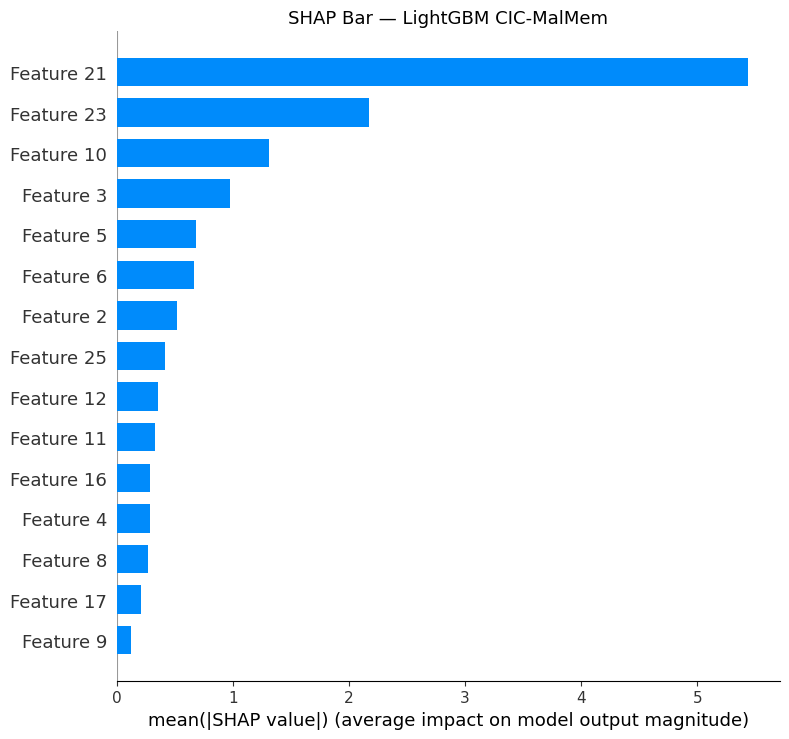

✅ shap_lgb_malmem_bar.png sauvegardé


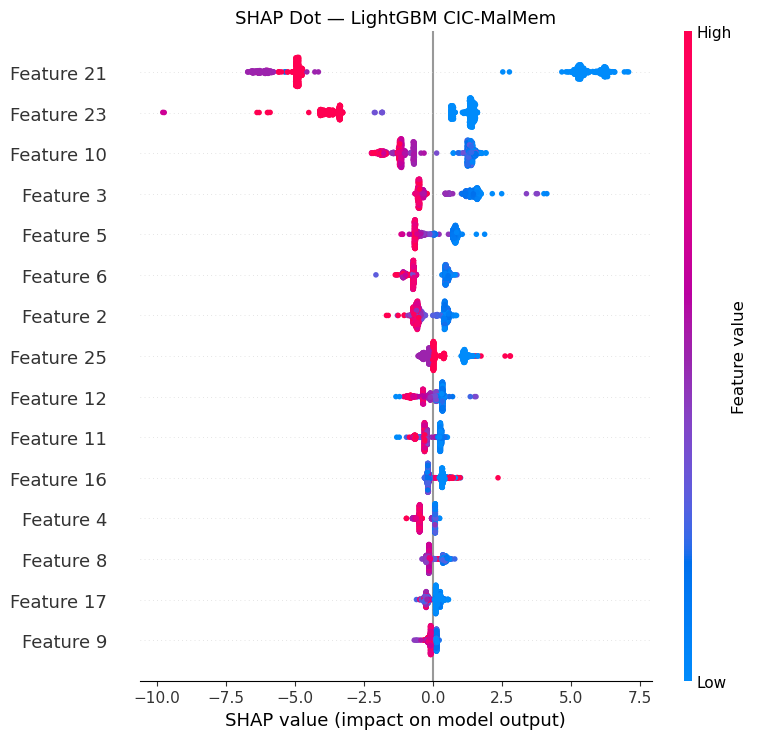

✅ shap_lgb_malmem_dot.png sauvegardé

SHAP — XGBoost CIC-MalMem


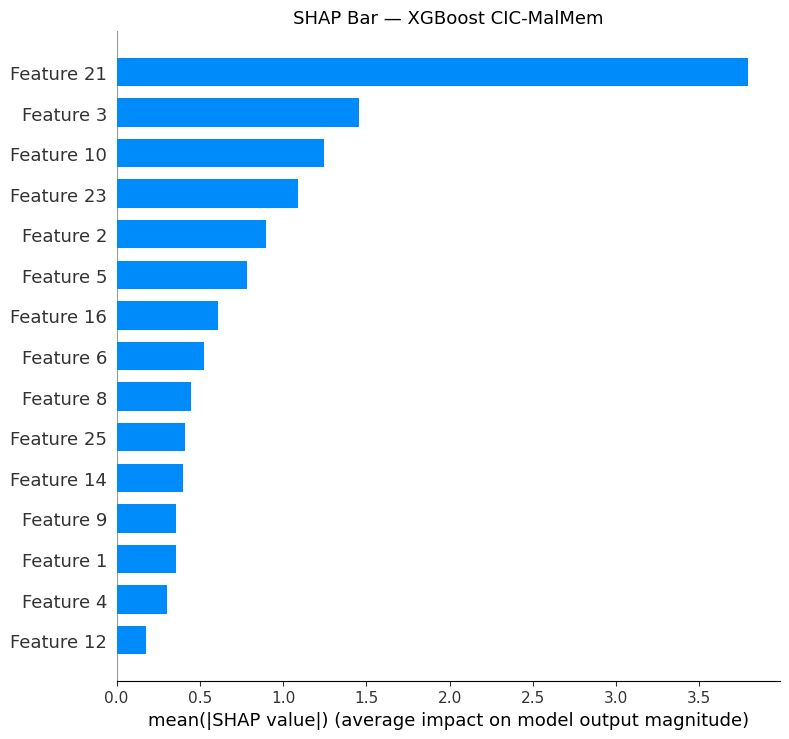

✅ shap_xgb_malmem_bar.png sauvegardé

SHAP — RF CIC-MalMem


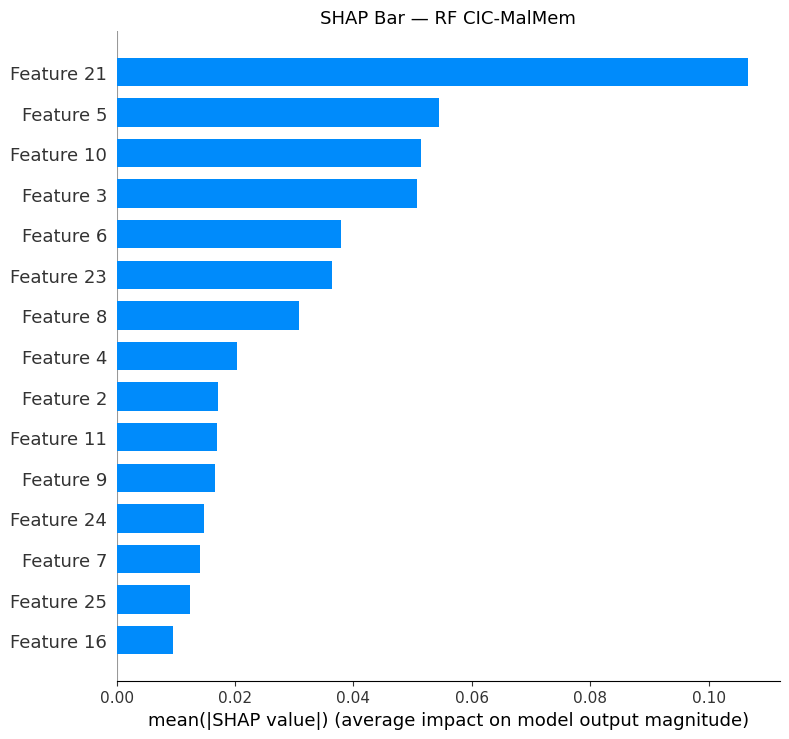

✅ shap_rf_malmem_bar.png sauvegardé

SHAP — LightGBM EMBER


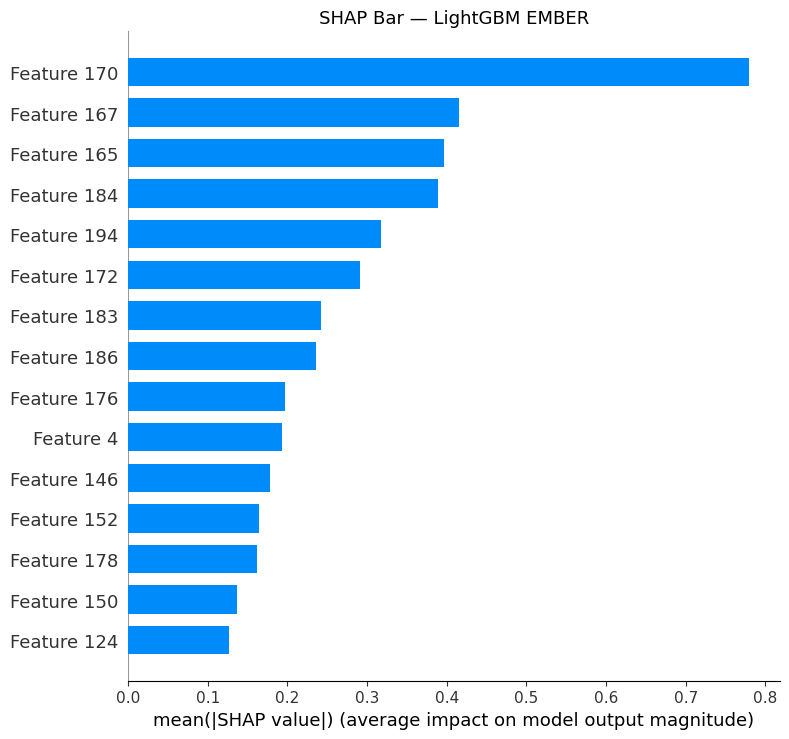

✅ shap_lgb_ember_bar.png sauvegardé


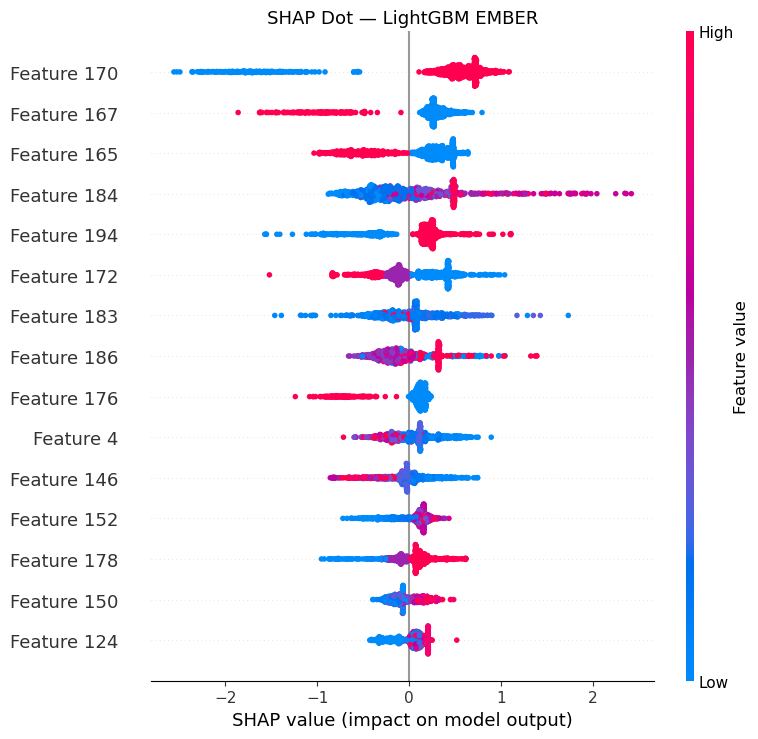

✅ shap_lgb_ember_dot.png sauvegardé

SHAP — XGBoost EMBER


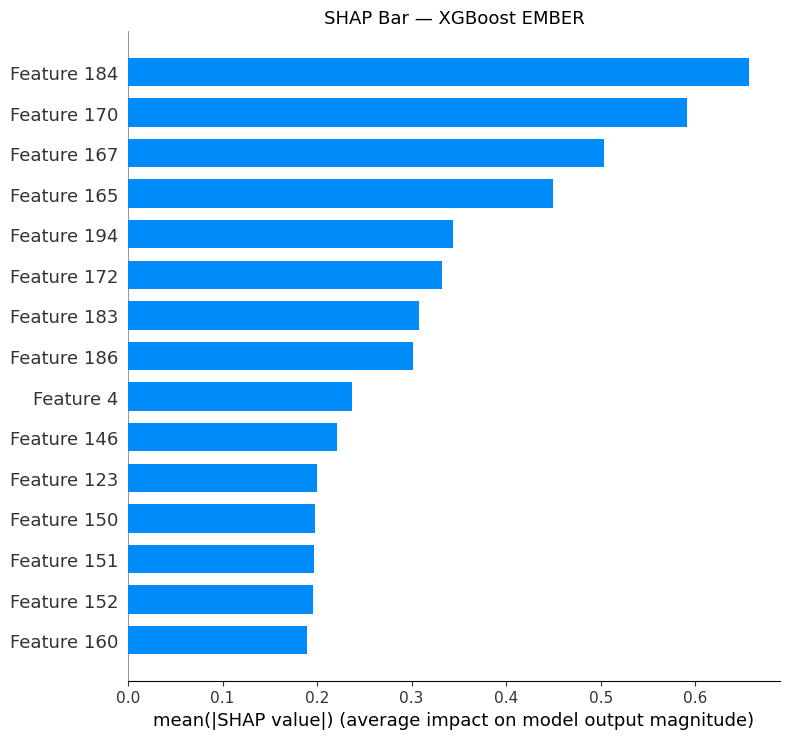

✅ shap_xgb_ember_bar.png sauvegardé

SHAP — RF EMBER


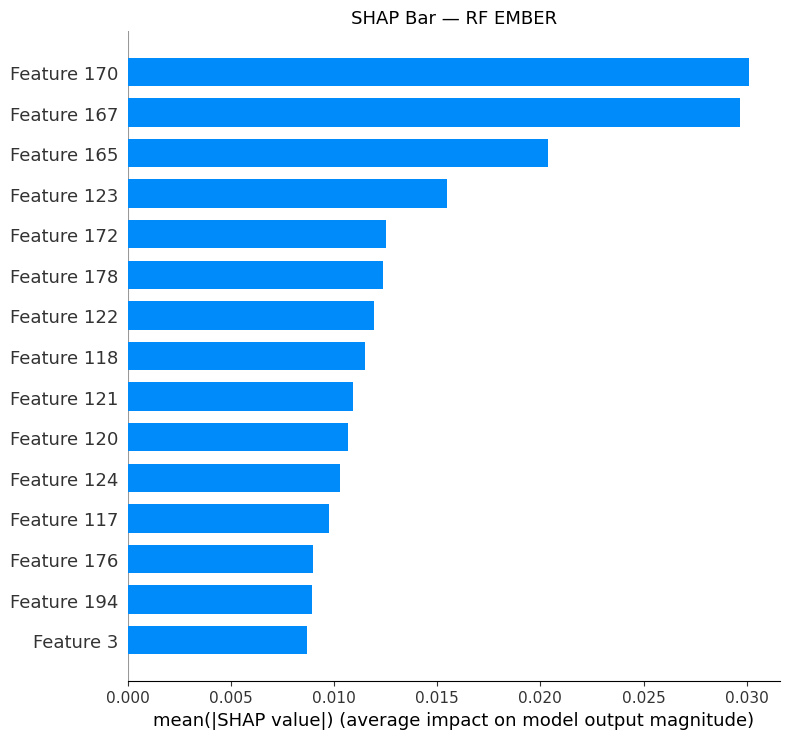

✅ shap_rf_ember_bar.png sauvegardé

RANKING UNIFIÉ — CIC-MalMem
    Feature_idx        RF   XGBoost  LightGBM  Mean_importance
21           21  0.106724  3.794315  5.439013         3.113351
23           23  0.036446  1.089413  2.173081         1.099647
10           10  0.051421  1.244204  1.309636         0.868421
3             3  0.050745  1.454986  0.973844         0.826525
5             5  0.054450  0.781181  0.686923         0.507518
2             2  0.017186  0.895895  0.523069         0.478717
6             6  0.037833  0.523051  0.668195         0.409693
16           16  0.009462  0.609886  0.289056         0.302801
25           25  0.012365  0.409631  0.415533         0.279176
8             8  0.030836  0.448772  0.273832         0.251146
4             4  0.020291  0.305070  0.283407         0.202923
12           12  0.009162  0.176293  0.360113         0.181856
9             9  0.016706  0.357008  0.121462         0.165059
14           14  0.001322  0.401773  0.089648         

In [3]:
# ============================================================
# Cellule 6 : SHAP Values — Analyse complète et comparative
# ============================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

results_dir = r"C:\PFA_Malware\results"

# 1000 samples — stable et représentatif
np.random.seed(42)
idx_m = np.random.choice(len(X_m_test), 1000, replace=False)
idx_e = np.random.choice(len(X_e_test), 1000, replace=False)
X_m_shap = X_m_test[idx_m]
X_e_shap = X_e_test[idx_e]

# ── Patch SHAP pour compatibilité XGBoost 2.x ───────────────
import shap.explainers._tree as _tree

_orig_init = _tree.XGBTreeModelLoader.__init__

def _patched_init(self, xgb_model):
    try:
        _orig_init(self, xgb_model)
    except ValueError:
        import json as _json
        config = _json.loads(xgb_model.save_config())
        raw = config["learner"]["learner_model_param"]["base_score"]
        if isinstance(raw, str) and raw.startswith("["):
            config["learner"]["learner_model_param"]["base_score"] = raw.strip("[]")
        original_save = xgb_model.save_config
        xgb_model.save_config = lambda: _json.dumps(config)
        _orig_init(self, xgb_model)
        xgb_model.save_config = original_save

_tree.XGBTreeModelLoader.__init__ = _patched_init
print("✅ Patch SHAP/XGBoost appliqué")

# ── Fonctions utilitaires ──────────────────────────────────
def extract_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    else:
        return shap_values

def plot_shap_bar(sv, X, title, filename):
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X, show=False, plot_type="bar", max_display=15)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ {filename} sauvegardé")

def plot_shap_dot(sv, X, title, filename):
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X, show=False, plot_type="dot", max_display=15)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ {filename} sauvegardé")

def get_top_features(sv, n=15):
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:n]
    return top_idx, mean_abs[top_idx]

shap_importances = {}

# ── LightGBM CIC-MalMem ────────────────────────────────────
print("="*55)
print("SHAP — LightGBM CIC-MalMem")
print("="*55)
explainer_lgb_m = shap.TreeExplainer(lgb_malmem_final)
sv_lgb_m = extract_shap_values(explainer_lgb_m.shap_values(X_m_shap))
plot_shap_bar(sv_lgb_m, X_m_shap, "SHAP Bar — LightGBM CIC-MalMem", "shap_lgb_malmem_bar.png")
plot_shap_dot(sv_lgb_m, X_m_shap, "SHAP Dot — LightGBM CIC-MalMem", "shap_lgb_malmem_dot.png")
top_idx, top_vals = get_top_features(sv_lgb_m)
shap_importances['LightGBM_MalMem'] = dict(zip(top_idx.astype(str), top_vals))

# ── XGBoost CIC-MalMem (PATCHED) ───────────────────────────
print("\n" + "="*55)
print("SHAP — XGBoost CIC-MalMem")
print("="*55)
explainer_xgb_m = shap.TreeExplainer(xgb_malmem_final)
sv_xgb_m = extract_shap_values(explainer_xgb_m.shap_values(X_m_shap))
plot_shap_bar(sv_xgb_m, X_m_shap, "SHAP Bar — XGBoost CIC-MalMem", "shap_xgb_malmem_bar.png")
top_idx, top_vals = get_top_features(sv_xgb_m)
shap_importances['XGBoost_MalMem'] = dict(zip(top_idx.astype(str), top_vals))

# ── RF CIC-MalMem ──────────────────────────────────────────
print("\n" + "="*55)
print("SHAP — RF CIC-MalMem")
print("="*55)
explainer_rf_m = shap.TreeExplainer(rf_malmem_final)
sv_rf_m = extract_shap_values(explainer_rf_m.shap_values(X_m_shap))
plot_shap_bar(sv_rf_m, X_m_shap, "SHAP Bar — RF CIC-MalMem", "shap_rf_malmem_bar.png")
top_idx, top_vals = get_top_features(sv_rf_m)
shap_importances['RF_MalMem'] = dict(zip(top_idx.astype(str), top_vals))

# ── LightGBM EMBER ─────────────────────────────────────────
print("\n" + "="*55)
print("SHAP — LightGBM EMBER")
print("="*55)
explainer_lgb_e = shap.TreeExplainer(lgb_ember_final)
sv_lgb_e = extract_shap_values(explainer_lgb_e.shap_values(X_e_shap))
plot_shap_bar(sv_lgb_e, X_e_shap, "SHAP Bar — LightGBM EMBER", "shap_lgb_ember_bar.png")
plot_shap_dot(sv_lgb_e, X_e_shap, "SHAP Dot — LightGBM EMBER", "shap_lgb_ember_dot.png")
top_idx, top_vals = get_top_features(sv_lgb_e)
shap_importances['LightGBM_EMBER'] = dict(zip(top_idx.astype(str), top_vals))

# ── XGBoost EMBER (PATCHED) ────────────────────────────────
print("\n" + "="*55)
print("SHAP — XGBoost EMBER")
print("="*55)
explainer_xgb_e = shap.TreeExplainer(xgb_ember_final)
sv_xgb_e = extract_shap_values(explainer_xgb_e.shap_values(X_e_shap))
plot_shap_bar(sv_xgb_e, X_e_shap, "SHAP Bar — XGBoost EMBER", "shap_xgb_ember_bar.png")
top_idx, top_vals = get_top_features(sv_xgb_e)
shap_importances['XGBoost_EMBER'] = dict(zip(top_idx.astype(str), top_vals))

# ── RF EMBER ───────────────────────────────────────────────
print("\n" + "="*55)
print("SHAP — RF EMBER")
print("="*55)
explainer_rf_e = shap.TreeExplainer(rf_ember_final)
sv_rf_e = extract_shap_values(explainer_rf_e.shap_values(X_e_shap))
plot_shap_bar(sv_rf_e, X_e_shap, "SHAP Bar — RF EMBER", "shap_rf_ember_bar.png")
top_idx, top_vals = get_top_features(sv_rf_e)
shap_importances['RF_EMBER'] = dict(zip(top_idx.astype(str), top_vals))

# ── Ranking cross-model CIC-MalMem ─────────────────────────
print("\n" + "="*55)
print("RANKING UNIFIÉ — CIC-MalMem")
print("="*55)

df_shap_m = pd.DataFrame({
    'Feature_idx': range(X_m_shap.shape[1]),
    'RF': np.abs(sv_rf_m).mean(axis=0),
    'XGBoost': np.abs(sv_xgb_m).mean(axis=0),
    'LightGBM': np.abs(sv_lgb_m).mean(axis=0),
})
df_shap_m['Mean_importance'] = df_shap_m[['RF','XGBoost','LightGBM']].mean(axis=1)
df_shap_m = df_shap_m.sort_values('Mean_importance', ascending=False).head(15)
print(df_shap_m.to_string())

# ── Ranking cross-model EMBER ──────────────────────────────
print("\n" + "="*55)
print("RANKING UNIFIÉ — EMBER")
print("="*55)

df_shap_e = pd.DataFrame({
    'Feature_idx': range(X_e_shap.shape[1]),
    'RF': np.abs(sv_rf_e).mean(axis=0),
    'XGBoost': np.abs(sv_xgb_e).mean(axis=0),
    'LightGBM': np.abs(sv_lgb_e).mean(axis=0),
})
df_shap_e['Mean_importance'] = df_shap_e[['RF','XGBoost','LightGBM']].mean(axis=1)
df_shap_e = df_shap_e.sort_values('Mean_importance', ascending=False).head(15)
print(df_shap_e.to_string())

# ── Sauvegarde ─────────────────────────────────────────────
df_shap_m.to_csv(os.path.join(results_dir, "shap_ranking_malmem.csv"), index=False)
df_shap_e.to_csv(os.path.join(results_dir, "shap_ranking_ember.csv"), index=False)

print("\n🎉 SHAP complet — pipeline final PRO terminé !")